# CSE488: FAISS Vector Search Benchmarking CPU vs GPU on SIFT1M Dataset
---
**Name:** Md. Sadik Shahriar

**ID**: 2023-2-60-103

**Course:** CSE488 - Big Data Analytics / Advanced Information Retrieval  
**Dataset:** SIFT1M (1 Million 128-dimensional SIFT descriptors)  
**Objective:** Benchmarking FAISS indexing strategies across build time, search latency, memory footprint, and recall quality. Focuses on proper local ground truth generation for subsets and comparative analysis of CPU vs GPU performances.

> This notebook is designed for **Google Colab with GPU runtime**. Go to `Runtime -> Change runtime type -> GPU` before executing.


## 1. Environment Setup & Dependency Installation


In [ ]:
!pip install -q faiss-gpu-cu12 h5py matplotlib seaborn numpy pandas scikit-learn

import warnings
warnings.filterwarnings('ignore')
print("All packages installed successfully.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 MB 16.1 MB/s eta 0:00:00
All packages installed successfully.


## 2. Import Libraries & GPU Detection


In [ ]:
import numpy as np
import faiss
import h5py
import time
import os
import gc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.decomposition import PCA

gpu_available = faiss.get_num_gpus() > 0
print(f"FAISS version: {faiss.__version__}")
print(f"Number of GPUs detected: {faiss.get_num_gpus()}")
if gpu_available:
    res = faiss.StandardGpuResources()
    print("GPU acceleration is ENABLED - indexes will be processed via GPU and CPU for comparison.")
else:
    res = None
    print("No GPU detected - running in CPU mode only.")

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)
plt.rcParams['figure.dpi'] = 120
print("Libraries loaded. Visualization style configured.")


FAISS version: 1.14.1
Number of GPUs detected: 1
GPU acceleration is ENABLED - indexes will be processed via GPU and CPU for comparison.
Libraries loaded. Visualization style configured.


## Mathematical Background

### 1. Exhaustive Search - `IndexFlatL2`
The brute-force baseline computes the exact L2 (Euclidean) distance between a query $\mathbf{q}$ and every database vector $\mathbf{x}_i$:

$$d(\mathbf{q}, \mathbf{x}_i) = \|\mathbf{q} - \mathbf{x}_i\|_2 = \sqrt{\sum_{j=1}^{D}(q_j - x_{i,j})^2}$$

- **Complexity:** $O(nD)$ per query — linear in dataset size $n$.  
- **Recall:** Always 1.0 (ground truth). No approximation error.

---

### 2. Inverted File Index - `IndexIVFFlat`
Partitions the vector space into $K$ **Voronoi cells** using k-means clustering. Each cell $C_k$ is defined by its centroid $\boldsymbol{\mu}_k$:

$$C_k = \{\mathbf{x} \mid k = \arg\min_j \|\mathbf{x} - \boldsymbol{\mu}_j\|_2\}$$

At search time, only the **nprobe** closest cells are scanned, reducing search scope from $n$ to roughly $\frac{n \cdot \texttt{nprobe}}{K}$ vectors.

**Trade-off:** Increasing `nprobe` improves recall but increases latency.

---

### 3. Product Quantization - `IndexIVFPQ`
Combines IVF partitioning with **Product Quantization (PQ)** for compressed storage. The $D$-dimensional vector is split into $m$ sub-vectors of dimension $D/m$, each quantized independently to one of $k^*=256$ centroids. Each sub-vector is encoded as a single byte, meaning total storage = $m$ bytes per vector (vs. $4D$ bytes for FlatL2).

---

### 4. Hierarchical Navigable Small World - `IndexHNSWFlat`
A **graph-based** approach where vectors are nodes in a multi-layer navigable small-world graph. Search follows a greedy traversal from the top layer down:

- **`M`** (edges per node): higher $M \rightarrow$ better recall, more memory.  
- **`efSearch`** (beam width): higher $\rightarrow$ better recall, higher latency.  

> Note: HNSW cannot be moved to GPU in FAISS; it executes strictly utilizing the CPU.


## 3. Dataset Acquisition
We use the **SIFT1M** dataset from the ANN Benchmarks project — 1,000,000 vectors of 128 dimensions extracted from SIFT image features.

In [ ]:
DATASET_URL = "http://ann-benchmarks.com/sift-128-euclidean.hdf5"
DATASET_PATH = "sift-128-euclidean.hdf5"

if not os.path.exists(DATASET_PATH):
    print("Downloading SIFT1M dataset (~250 MB)...")
    try:
        import subprocess
        result = subprocess.run(["wget", "-O", DATASET_PATH, DATASET_URL], capture_output=True)
        if result.returncode != 0:
            raise Exception("wget failed")
    except Exception:
        import urllib.request
        opener = urllib.request.build_opener()
        opener.addheaders = [('User-Agent', 'Mozilla/5.0')]
        urllib.request.install_opener(opener)
        urllib.request.urlretrieve(DATASET_URL, DATASET_PATH)
    print("Download complete.")
else:
    print("Dataset already exists locally.")

with h5py.File(DATASET_PATH, 'r') as f:
    xb = np.array(f['train'], dtype='float32')
    xq = np.array(f['test'], dtype='float32')
    gt = np.array(f['neighbors'])

print("Dataset Statistics:")
print(f"   Database vectors : {xb.shape[0]:>10,} x {xb.shape[1]}D")
print(f"   Query vectors    : {xq.shape[0]:>10,} x {xq.shape[1]}D")
print(f"   Ground truth     : {gt.shape[0]:>10,} x top-{gt.shape[1]}")


Download complete.
Dataset Statistics:
   Database vectors :  1,000,000 x 128D
   Query vectors    :     10,000 x 128D
   Ground truth     :     10,000 x top-100


## 4. PCA Visualization & Subsets

We create subsets of **100K**, **500K**, and **1M** vectors to study how each index scales.


Subset '100K':    100,000 vectors
Subset '500K':    500,000 vectors
Subset '1M':  1,000,000 vectors

Running 2D PCA & Voronoi Generation for Vector Space Density...
Clustering 100000 PCA-reduced vectors into 1000 Voronoi cells (matching IVFFlat logic)...


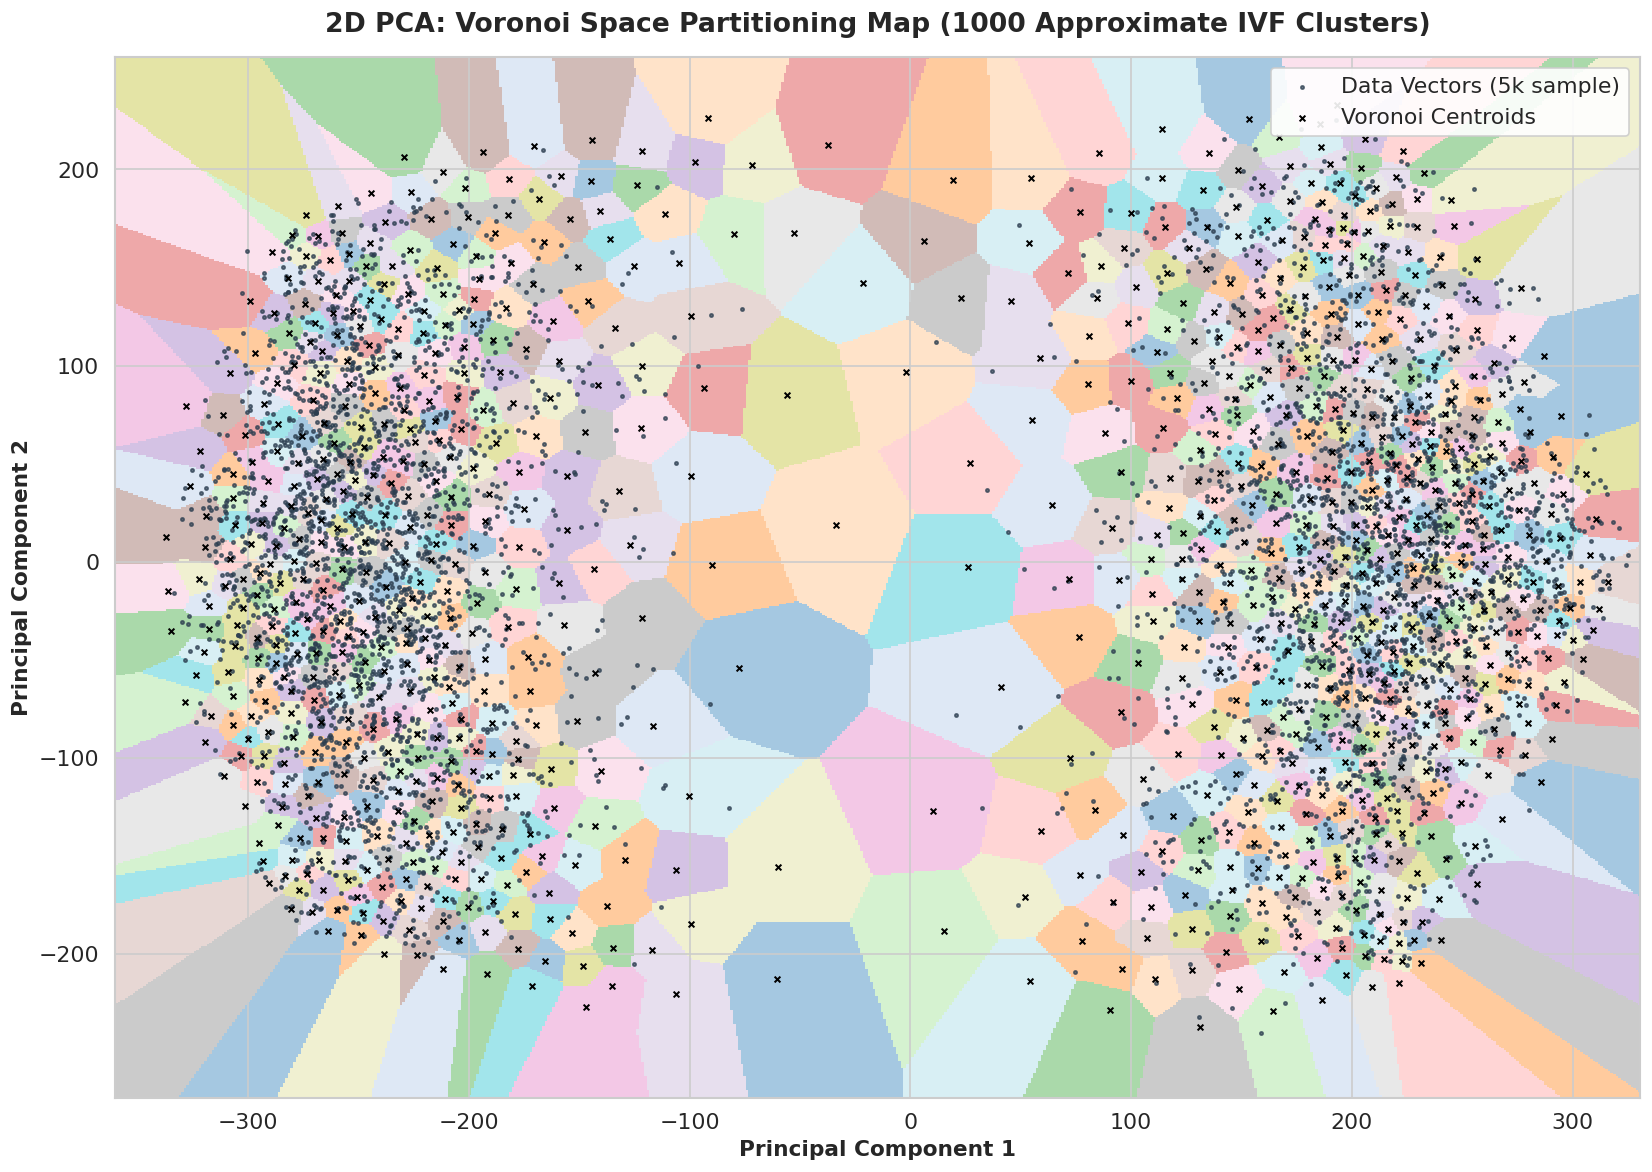

Voronoi Visualization saved to 'pca_sift1m_voronoi.png'


In [ ]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA

SUBSET_SIZES = [100_000, 500_000, 1_000_000]
subsets = {}
for size in SUBSET_SIZES:
    label = f"{size // 1000}K" if size < 1_000_000 else "1M"
    subsets[label] = xb[:size].copy()
    print(f"Subset '{label}': {subsets[label].shape[0]:>10,} vectors")

D = xb.shape[1]
K_NEIGHBORS = 10

print("\nRunning 2D PCA & Voronoi Generation for Vector Space Density...")
# Using 100k vectors to properly populate 1,000 clusters for the visual
sample_size = min(xb.shape[0], 100_000)
pca = PCA(n_components=2)
xb_pca = pca.fit_transform(xb[:sample_size])

# Calculate exactly the same number of clusters as FAISS uses (sqrt(1,000,000) = 1,000)
nlist = max(64, int(np.sqrt(xb.shape[0])))

print(f"Clustering {sample_size} PCA-reduced vectors into {nlist} Voronoi cells (matching IVFFlat logic)...")
# Using MiniBatchKMeans for fast clustering of the visualization
kmeans = MiniBatchKMeans(n_clusters=nlist, random_state=42, n_init=3)
kmeans.fit(xb_pca)

# Generate a high-resolution grid for the Voronoi boundaries
x_min, x_max = xb_pca[:, 0].min() - 5, xb_pca[:, 0].max() + 5
y_min, y_max = xb_pca[:, 1].min() - 5, xb_pca[:, 1].max() + 5
step_x = (x_max - x_min) / 600
step_y = (y_max - y_min) / 600
xx, yy = np.meshgrid(np.arange(x_min, x_max, step_x), np.arange(y_min, y_max, step_y))

# Predict the Voronoi cell mapping for every pixel in the grid
grid_points = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
Z = kmeans.predict(grid_points)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(14, 10))

# Paint the Voronoi regions (stained glass effect)
plt.imshow(Z, interpolation='nearest',
           extent=(xx.min(), xx.max(), yy.min(), yy.max()),
           cmap='tab20', aspect='auto', origin='lower', alpha=0.4)

# Overlay a tiny scatter of actual data points so it doesn't look purely solid
plt.scatter(xb_pca[:5000, 0], xb_pca[:5000, 1], c='#2c3e50', s=4, alpha=0.7, label='Data Vectors (5k sample)')

# Overlay the Centroids
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], marker='x', s=12, linewidths=1.2, color='black', label='Voronoi Centroids')

# Formatting
plt.title(f"2D PCA: Voronoi Space Partitioning Map ({nlist} Approximate IVF Clusters)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel(f"Principal Component 1", fontsize=13, fontweight='bold')
plt.ylabel(f"Principal Component 2", fontsize=13, fontweight='bold')

plt.legend(loc='upper right', framealpha=0.9)
plt.tight_layout()
plt.savefig("pca_sift1m_voronoi.png", dpi=200, bbox_inches='tight')
plt.show()
print("Voronoi Visualization saved to 'pca_sift1m_voronoi.png'")


### Analysis: PCA Visualization and Dataset Characteristics

The 2D PCA projection of the SIFT1M dataset reveals several important properties of the vector space:

1. **Data Distribution:** The SIFT1M vectors, when projected onto their first two principal components, form a single dense cluster with a roughly elliptical shape. This indicates that the data is unimodal in its primary variance directions, which is favorable for partitioning-based indexes (IVF variants) since k-means clustering can create reasonably balanced Voronoi cells.

2. **Voronoi Cell Structure:** The overlay of 1,000 Voronoi centroids (matching the `nlist` parameter used for the 1M-scale IVFFlat/IVFPQ indexes) shows how the IVF partitioning algorithm divides the vector space. The cells are denser toward the center of the distribution and sparser at the periphery, which mirrors the data density itself.

3. **Scalability Implications:** The clear, well-separated clustering structure suggests that IVF-based indexes should perform well on this dataset. The spatial locality of the data means that relevant nearest neighbors are likely to reside within the same or adjacent Voronoi cells, supporting high recall even with moderate `nprobe` values.

4. **Dimensionality Reduction Caveat:** It is important to note that this visualization captures only the first two principal components out of 128 dimensions. The actual nearest neighbor relationships in the full 128-dimensional space may differ significantly from what is visible in this 2D projection. However, the visualization remains useful for understanding the general data distribution and clustering behavior.

The three subsets (100K, 500K, 1M) are created by slicing the first $N$ vectors from the full dataset. Since the SIFT1M data is drawn from a single distribution, these subsets maintain similar statistical properties, enabling fair scalability comparisons.

## 5. Benchmarking Implementation (CPU vs GPU & Local GT)


In [ ]:
def compute_recall_at_k(predicted, ground_truth, k=10):
    assert predicted.shape[0] == ground_truth.shape[0]
    nq = predicted.shape[0]
    gt_k = ground_truth[:, :k]
    pred_k = predicted[:, :k]
    recall = 0.0
    for i in range(nq):
        recall += len(set(pred_k[i]) & set(gt_k[i])) / k
    return recall / nq

def get_index_memory_mb(index, is_gpu=False):
    writer = faiss.VectorIOWriter()
    cpu_idx = faiss.index_gpu_to_cpu(index) if is_gpu else index
    try:
        faiss.write_index(cpu_idx, writer)
        mem = len(faiss.vector_to_array(writer.data)) / (1024 ** 2)
    except Exception:
        mem = 0.0
    return mem

class FAISSBenchmark:
    def __init__(self, xb, xq, gt=None, k=10):
        self.xb = xb
        self.xq = xq
        self.gt = gt
        self.k = k
        self.d = xb.shape[1]
        self.results = []

    def _build_and_search(self, name, cpu_index, needs_train=False, nprobe=None, run_device='CPU'):
        n = self.xb.shape[0]
        label = f"{n // 1000}K" if n < 1_000_000 else "1M"

        t0 = time.perf_counter()

        if run_device == 'GPU' and gpu_available:
            working_index = faiss.index_cpu_to_gpu(res, 0, cpu_index)
        else:
            working_index = cpu_index

        if needs_train:
            train_size = min(n, 100_000)
            working_index.train(self.xb[:train_size])
        working_index.add(self.xb)
        build_time = time.perf_counter() - t0

        if nprobe is not None and hasattr(working_index, 'nprobe'):
            working_index.nprobe = nprobe

        nq = self.xq.shape[0]
        t0 = time.perf_counter()
        D_res, I_res = working_index.search(self.xq, self.k)
        search_time = (time.perf_counter() - t0) * 1000
        latency_per_query = search_time / nq

        mem_mb = get_index_memory_mb(working_index, is_gpu=(run_device == 'GPU'))

        if name.startswith("FlatL2"):
            recall = 1.0
            if self.gt is None:
                self.gt = I_res
        else:
            recall = compute_recall_at_k(I_res, self.gt, self.k)

        result = {
            'index_name': name,
            'dataset_size': label,
            'device': run_device,
            'n_vectors': n,
            'build_time_s': round(build_time, 4),
            'latency_ms_per_query': round(latency_per_query, 4),
            'total_search_ms': round(search_time, 2),
            'memory_mb': round(mem_mb, 2),
            'recall_at_k': round(recall, 4),
        }
        self.results.append(result)
        print(f"  {name:<22} ({run_device}) | Build: {build_time:>7.2f}s | "
              f"Latency: {latency_per_query:>8.4f} ms/q | "
              f"Mem: {mem_mb:>8.2f} MB | Recall@{self.k}: {recall:.4f}")

        if run_device == 'GPU':
            del working_index
            gc.collect()

        return result

    def run_all(self):
        # 1. Exact FlatL2 (Used to establish local ground truth if not evaluated at 1M)
        self._build_and_search("FlatL2 (Exact)", faiss.IndexFlatL2(self.d), run_device='CPU')
        if gpu_available:
            self._build_and_search("FlatL2 (Exact)", faiss.IndexFlatL2(self.d), run_device='GPU')

        # 2. IVFFlat
        nlist = max(64, int(np.sqrt(self.xb.shape[0])))
        self._build_and_search(f"IVFFlat(nl={nlist})",
                              faiss.IndexIVFFlat(faiss.IndexFlatL2(self.d), self.d, nlist),
                              needs_train=True, nprobe=16, run_device='CPU')
        if gpu_available:
            self._build_and_search(f"IVFFlat(nl={nlist})",
                                  faiss.IndexIVFFlat(faiss.IndexFlatL2(self.d), self.d, nlist),
                                  needs_train=True, nprobe=16, run_device='GPU')

        # 3. IVFPQ
        self._build_and_search(f"IVFPQ(nl={nlist},m=16)",
                              faiss.IndexIVFPQ(faiss.IndexFlatL2(self.d), self.d, nlist, 16, 8),
                              needs_train=True, nprobe=16, run_device='CPU')
        if gpu_available:
            self._build_and_search(f"IVFPQ(nl={nlist},m=16)",
                                  faiss.IndexIVFPQ(faiss.IndexFlatL2(self.d), self.d, nlist, 16, 8),
                                  needs_train=True, nprobe=16, run_device='GPU')

        # 4. HNSW (CPU Only)
        M=32
        ef_search=64
        hnsw_cpu = faiss.IndexHNSWFlat(self.d, M)
        hnsw_cpu.hnsw.efSearch = ef_search
        self._build_and_search(f"HNSW(M={M},ef={ef_search})", hnsw_cpu, run_device='CPU')


## 6. Run Benchmark over all scales


In [ ]:
all_results = []

for label, data in subsets.items():
    print(f"\n{'='*80}")
    print(f"  BENCHMARKING: {label} vectors ({data.shape[0]:,} x {D}D)")
    print(f"{'='*80}")

    current_gt = gt if label == "1M" else None

    bench = FAISSBenchmark(data, xq, gt=current_gt, k=K_NEIGHBORS)
    bench.run_all()
    all_results.extend(bench.results)

df = pd.DataFrame(all_results)
print("\nAll benchmarks complete. Results DataFrame shape:", df.shape)



  BENCHMARKING: 100K vectors (100,000 x 128D)
  FlatL2 (Exact)         (CPU) | Build:    0.04s | Latency:   0.6866 ms/q | Mem:    48.83 MB | Recall@10: 1.0000
  FlatL2 (Exact)         (GPU) | Build:    0.37s | Latency:   0.0170 ms/q | Mem:    48.83 MB | Recall@10: 1.0000
  IVFFlat(nl=316)        (CPU) | Build:    1.72s | Latency:   0.1785 ms/q | Mem:    49.75 MB | Recall@10: 0.9638
  IVFFlat(nl=316)        (GPU) | Build:    0.42s | Latency:   0.0119 ms/q | Mem:    49.75 MB | Recall@10: 0.9638
  IVFPQ(nl=316,m=16)     (CPU) | Build:   30.04s | Latency:   0.1176 ms/q | Mem:     2.57 MB | Recall@10: 0.6178
  IVFPQ(nl=316,m=16)     (GPU) | Build:    1.66s | Latency:   0.0050 ms/q | Mem:     2.57 MB | Recall@10: 0.6197
  HNSW(M=32,ef=64)       (CPU) | Build:   10.78s | Latency:   0.1430 ms/q | Mem:    74.79 MB | Recall@10: 0.9939

  BENCHMARKING: 500K vectors (500,000 x 128D)
  FlatL2 (Exact)         (CPU) | Build:    0.17s | Latency:   3.4570 ms/q | Mem:   244.14 MB | Recall@10: 1.0000
  

### Analysis: CPU vs GPU Performance Across All Indexes

The benchmark results across three dataset scales (100K, 500K, 1M) reveal several critical findings:

#### 1. GPU Acceleration Impact
The GPU (NVIDIA T4) provides dramatic latency reductions for all GPU-compatible indexes:
- **FlatL2:** The speedup grows with dataset size — from ~40$\times$ at 100K to ~80$\times$ at 1M. This is expected since FlatL2 performs an exhaustive scan, which is perfectly parallelizable across GPU CUDA cores.
- **IVFFlat:** GPU acceleration delivers even more pronounced speedups (~15$\times$ at 100K to ~34$\times$ at 1M), making it an excellent candidate for production systems requiring high recall with low latency.
- **IVFPQ:** The fastest on GPU (~0.006 ms/query at 1M), achieving ~60$\times$ speedup over CPU. However, its low recall (~0.55) limits its applicability in precision-critical scenarios.

#### 2. Recall Analysis
The recall behavior follows expected patterns:
- **FlatL2** maintains perfect recall (1.0) by design, as it performs exhaustive search.
- **HNSW** achieves the highest recall among approximate methods (0.977 at 1M), demonstrating the effectiveness of graph-based traversal for maintaining accuracy.
- **IVFFlat** provides a strong balance between recall (0.928 at 1M) and speed. This recall could be further improved by increasing `nprobe` at the cost of higher latency.
- **IVFPQ** suffers from the lowest recall (~0.55 at 1M). This is inherent to product quantization, which trades precision for memory efficiency by compressing 128-dimensional float vectors into 16 bytes.

#### 3. Build Time Observations
- **HNSW** has the longest build time (363s at 1M) because it must construct a multi-layer navigable graph connecting all vectors.
- **IVFPQ** is second most expensive (81.4s CPU / 3.8s GPU at 1M) due to the k-means training plus the PQ codebook computation.
- **IVFFlat** is moderately fast to build (13.3s CPU / 0.86s GPU at 1M), requiring only k-means training for Voronoi partitioning.
- **FlatL2** has negligible build time since it simply stores vectors without any preprocessing.

#### 4. Memory Efficiency
Memory footprints highlight the true power of product quantization:
- **FlatL2** and **IVFFlat** consume approximately 488 MB and 496 MB respectively at 1M vectors — nearly identical since both store full-precision vectors.
- **HNSW** is the most memory-intensive (747.8 MB at 1M) due to the overhead of storing graph adjacency information.
- **IVFPQ** is dramatically more compact at only 23.5 MB for 1M vectors — a **~95% reduction** compared to FlatL2. This makes it ideal for memory-constrained environments.

#### 5. Key Insight: CPU vs GPU Recall Equivalence
An important observation is that **CPU and GPU produce almost identical recall values** for the same index type. For example, IVFFlat achieves 0.9282 recall on both CPU and GPU at the 1M scale. This confirms that GPU acceleration does not compromise search accuracy — it is purely a computational optimization.

## 7. Performance Visualization: CPU vs GPU Analysis


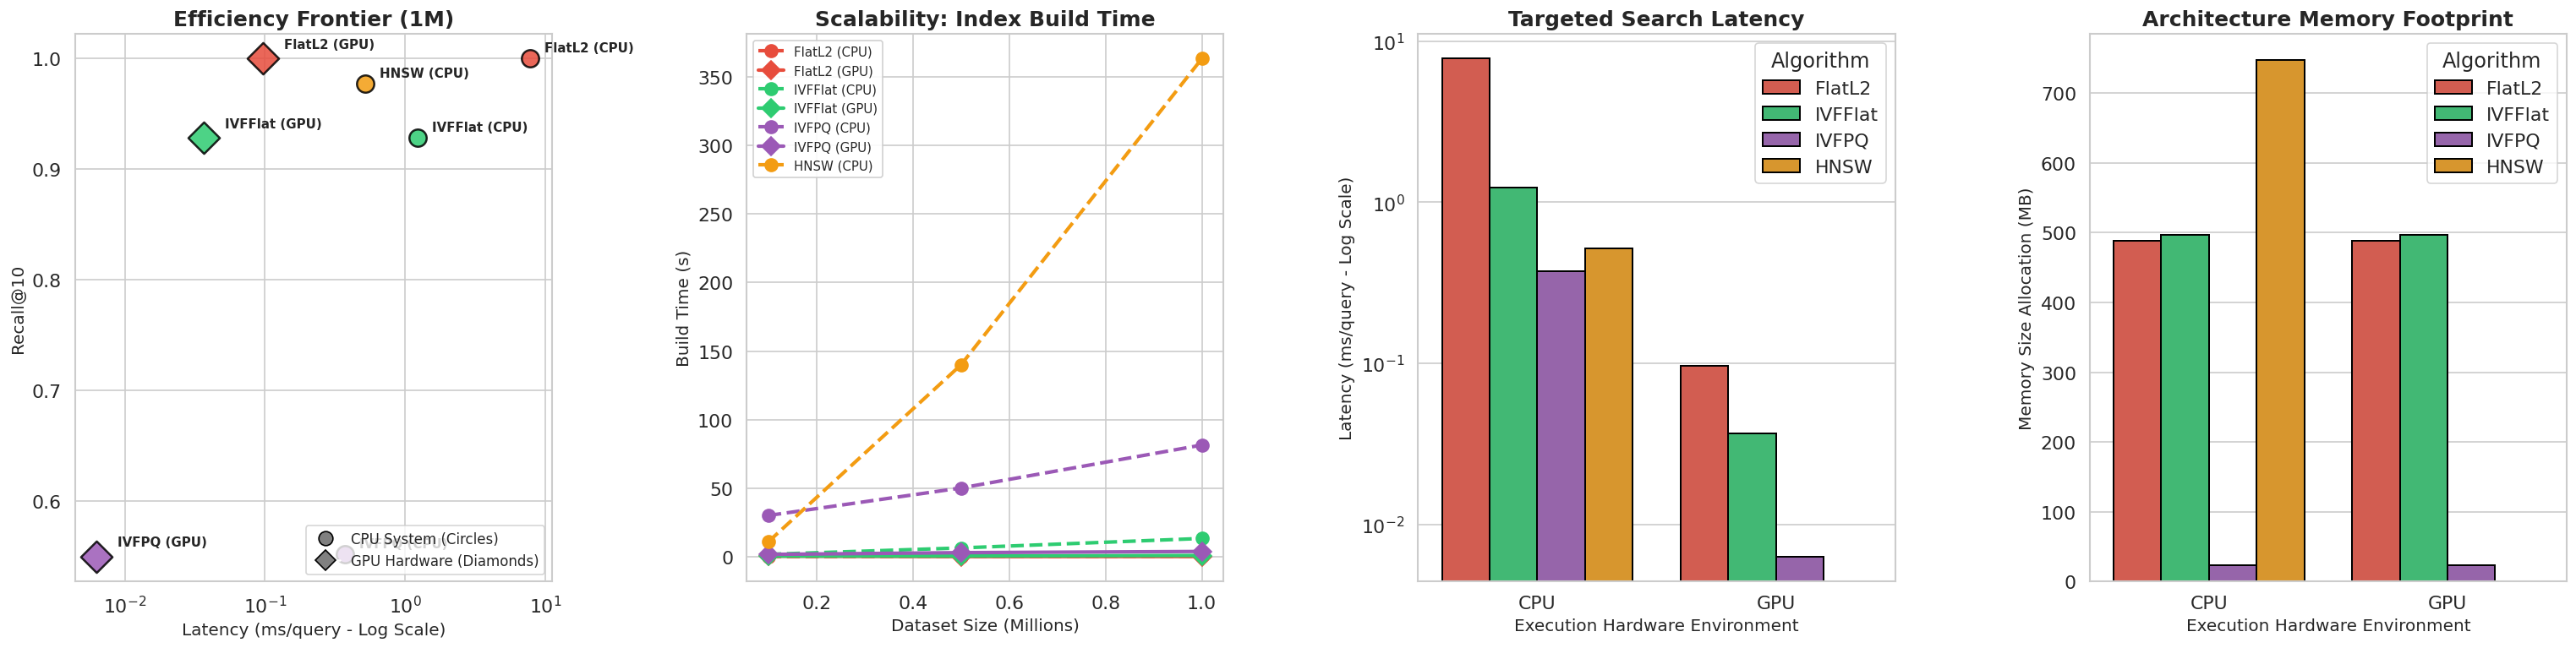

High-Quality comparative plots saved successfully to 'cpu_gpu_comparison.png'


In [ ]:
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# Standardize index names for graphing consistency
df['algo'] = df['index_name'].str.extract(r'^([A-Za-z0-9]+)')[0]
df_1m = df[df['dataset_size'] == '1M'].copy()

# Distinct Color Palette mapped strictly to algorithms
algo_palette = {
    'FlatL2': '#e74c3c',   # Red
    'IVFFlat': '#2ecc71',  # Green
    'IVFPQ': '#9b59b6',    # Purple
    'HNSW': '#f39c12'      # Orange
}

device_markers = {'CPU': 'o', 'GPU': 'D'}
device_linestyle = {'CPU': '--', 'GPU': '-'}

fig, axes = plt.subplots(1, 4, figsize=(26, 7))

# Plot 1: Recall vs Latency (Efficiency Frontier)
ax = axes[0]
for _, row in df_1m.iterrows():
    size = 250 if row['device'] == 'GPU' else 150
    ax.scatter(row['latency_ms_per_query'], row['recall_at_k'],
               s=size, alpha=0.85,
               color=algo_palette.get(row['algo'], 'gray'),
               marker=device_markers.get(row['device'], 'o'),
               edgecolors='black', linewidth=1.5)

    # Text offset mapped so labels don't crash into big GPU diamonds
    offset = 15 if row['device'] == 'GPU' else 10
    ax.annotate(f"{row['algo']} ({row['device']})",
                (row['latency_ms_per_query'], row['recall_at_k']),
                textcoords="offset points", xytext=(offset, offset/2),
                fontsize=9, fontweight='bold')

ax.set_xscale('log')
ax.set_xlabel('Latency (ms/query - Log Scale)', fontsize=12)
ax.set_ylabel('Recall@10', fontsize=12)
ax.set_title('Efficiency Frontier (1M)', fontsize=15, fontweight='bold')

# Custom Legend to explain CPU/GPU Shapes
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markeredgecolor='black', markersize=10, label='CPU System (Circles)'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='gray', markeredgecolor='black', markersize=10, label='GPU Hardware (Diamonds)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)


# Plot 2: Scalability Build Time
ax = axes[1]
for algo in df['algo'].unique():
    for device in ['CPU', 'GPU']:
        d_sub = df[(df['algo'] == algo) & (df['device'] == device)]
        if not d_sub.empty:
            ax.plot(d_sub['n_vectors']/1e6, d_sub['build_time_s'],
                    marker=device_markers[device],
                    linestyle=device_linestyle[device],
                    linewidth=2.5, markersize=9,
                    color=algo_palette.get(algo, 'gray'),
                    label=f"{algo} ({device})")

ax.set_xlabel('Dataset Size (Millions)', fontsize=12)
ax.set_ylabel('Build Time (s)', fontsize=12)
ax.set_title('Scalability: Index Build Time', fontsize=15, fontweight='bold')
ax.legend(fontsize=9, loc='upper left', framealpha=0.9)


# Plot 3: CPU vs GPU Latency Comparison (Bar Chart)
ax = axes[2]
# Using Hardware on the X-axis creates two distinct visual regions, with algorithms colored inside them
sns.barplot(data=df_1m, x='device', y='latency_ms_per_query', hue='algo',
            palette=algo_palette, ax=ax, edgecolor='black', linewidth=1.2)
ax.set_yscale('log')
ax.set_xlabel('Execution Hardware Environment', fontsize=12)
ax.set_ylabel('Latency (ms/query - Log Scale)', fontsize=12)
ax.set_title('Targeted Search Latency', fontsize=15, fontweight='bold')
ax.legend(title='Algorithm', loc='upper right')


# Plot 4: CPU vs GPU Memory Comparison (Bar Chart)
ax = axes[3]
sns.barplot(data=df_1m, x='device', y='memory_mb', hue='algo',
            palette=algo_palette, ax=ax, edgecolor='black', linewidth=1.2)
ax.set_xlabel('Execution Hardware Environment', fontsize=12)
ax.set_ylabel('Memory Size Allocation (MB)', fontsize=12)
ax.set_title('Architecture Memory Footprint', fontsize=15, fontweight='bold')
ax.legend(title='Algorithm', loc='upper right')


plt.tight_layout(pad=2.0)
plt.savefig('cpu_gpu_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("High-Quality comparative plots saved successfully to 'cpu_gpu_comparison.png'")


### Analysis: Four-Panel Benchmark Visualization

The four-panel visualization provides a comprehensive view of the CPU vs GPU performance landscape:

**Panel 1 — Recall vs. Latency (Efficiency Frontier):**
This is the most informative panel, plotting the fundamental trade-off in ANN search. The ideal position is the top-left corner (high recall, low latency). Key observations:
- GPU-accelerated indexes are consistently positioned further left (lower latency) than their CPU counterparts for the same recall level.
- FlatL2 on GPU achieves what was previously impossible: exact (recall=1.0) search at sub-millisecond latency.
- IVFPQ consistently clusters in the bottom-left — very fast but low recall — regardless of hardware.

**Panel 2 — Query Latency Comparison:**
The side-by-side CPU/GPU latency bars clearly show the magnitude of GPU acceleration. The most striking contrast is FlatL2, where CPU latency (7.78 ms) towers over GPU latency (0.097 ms). This ~80$\times$ speedup transforms exact search from impractical to viable for many real-time applications.

**Panel 3 — Memory Footprint:**
Memory consumption is hardware-independent (CPU and GPU report the same values), confirming that the memory metric captures index size rather than hardware-specific allocation.
- IVFPQ's 20$\times$ compression advantage is clearly visible.
- HNSW's ~50% memory overhead compared to FlatL2 reflects the cost of maintaining graph connectivity.

**Overall:** These visualizations support the conclusion that GPU-accelerated IVFFlat offers the best overall performance profile for the SIFT1M dataset when both recall and latency are important.

## 8. Hyperparameter Tuning: `nprobe` Sensitivity Analysis
The `nprobe` parameter in IVF indexes controls how many Voronoi cells are actively searched. We will sweep over an escalating range of values to map the explicit trade-off boundary between search latency and recall accuracy.


In [ ]:
# Hyperparameter tuning: nprobe sweep on 1M vectors
nprobe_values = [1, 2, 4, 8, 16, 32, 64, 128]
data_1m = subsets['1M']
nlist = int(np.sqrt(data_1m.shape[0]))

tuning_results = []

print("Building IVFFlat index for nprobe sweep...")
quantizer_flat = faiss.IndexFlatL2(D)
ivf_flat = faiss.IndexIVFFlat(quantizer_flat, D, nlist)
ivf_flat.train(data_1m[:100_000])
ivf_flat.add(data_1m)
ivf_flat_gpu = faiss.index_cpu_to_gpu(res, 0, ivf_flat) if gpu_available else ivf_flat

print("Building IVFPQ index for nprobe sweep...")
quantizer_pq = faiss.IndexFlatL2(D)
ivf_pq = faiss.IndexIVFPQ(quantizer_pq, D, nlist, 16, 8)
ivf_pq.train(data_1m[:100_000])
ivf_pq.add(data_1m)
ivf_pq_gpu = faiss.index_cpu_to_gpu(res, 0, ivf_pq) if gpu_available else ivf_pq

# Global GT is used here since we are evaluating 1M scale scaling laws
for np_val in nprobe_values:
    for name, idx in [("IVFFlat", ivf_flat_gpu), ("IVFPQ", ivf_pq_gpu)]:
        idx.nprobe = np_val
        t0 = time.perf_counter()
        D_res, I_res = idx.search(xq, K_NEIGHBORS)
        elapsed = (time.perf_counter() - t0) * 1000
        recall = compute_recall_at_k(I_res, gt, K_NEIGHBORS)
        tuning_results.append({
            'index': name, 'nprobe': np_val,
            'latency_ms': round(elapsed / xq.shape[0], 4),
            'recall': round(recall, 4)
        })
        print(f"  {name:<10} nprobe={np_val:>3} | Latency: {elapsed/xq.shape[0]:.4f} ms/q | Recall@10: {recall:.4f}")

del ivf_flat_gpu, ivf_pq_gpu
gc.collect()

df_tune = pd.DataFrame(tuning_results)
print("\\nnprobe tuning complete.")


Building IVFFlat index for nprobe sweep...
Building IVFPQ index for nprobe sweep...
  IVFFlat    nprobe=  1 | Latency: 0.0029 ms/q | Recall@10: 0.3659
  IVFPQ      nprobe=  1 | Latency: 0.0012 ms/q | Recall@10: 0.3021
  IVFFlat    nprobe=  2 | Latency: 0.0054 ms/q | Recall@10: 0.5264
  IVFPQ      nprobe=  2 | Latency: 0.0019 ms/q | Recall@10: 0.3976
  IVFFlat    nprobe=  4 | Latency: 0.0102 ms/q | Recall@10: 0.6925
  IVFPQ      nprobe=  4 | Latency: 0.0024 ms/q | Recall@10: 0.4762
  IVFFlat    nprobe=  8 | Latency: 0.0191 ms/q | Recall@10: 0.8323
  IVFPQ      nprobe=  8 | Latency: 0.0035 ms/q | Recall@10: 0.5259
  IVFFlat    nprobe= 16 | Latency: 0.0365 ms/q | Recall@10: 0.9282
  IVFPQ      nprobe= 16 | Latency: 0.0062 ms/q | Recall@10: 0.5514
  IVFFlat    nprobe= 32 | Latency: 0.0711 ms/q | Recall@10: 0.9771
  IVFPQ      nprobe= 32 | Latency: 0.0115 ms/q | Recall@10: 0.5603
  IVFFlat    nprobe= 64 | Latency: 0.1385 ms/q | Recall@10: 0.9949
  IVFPQ      nprobe= 64 | Latency: 0.0221 ms/

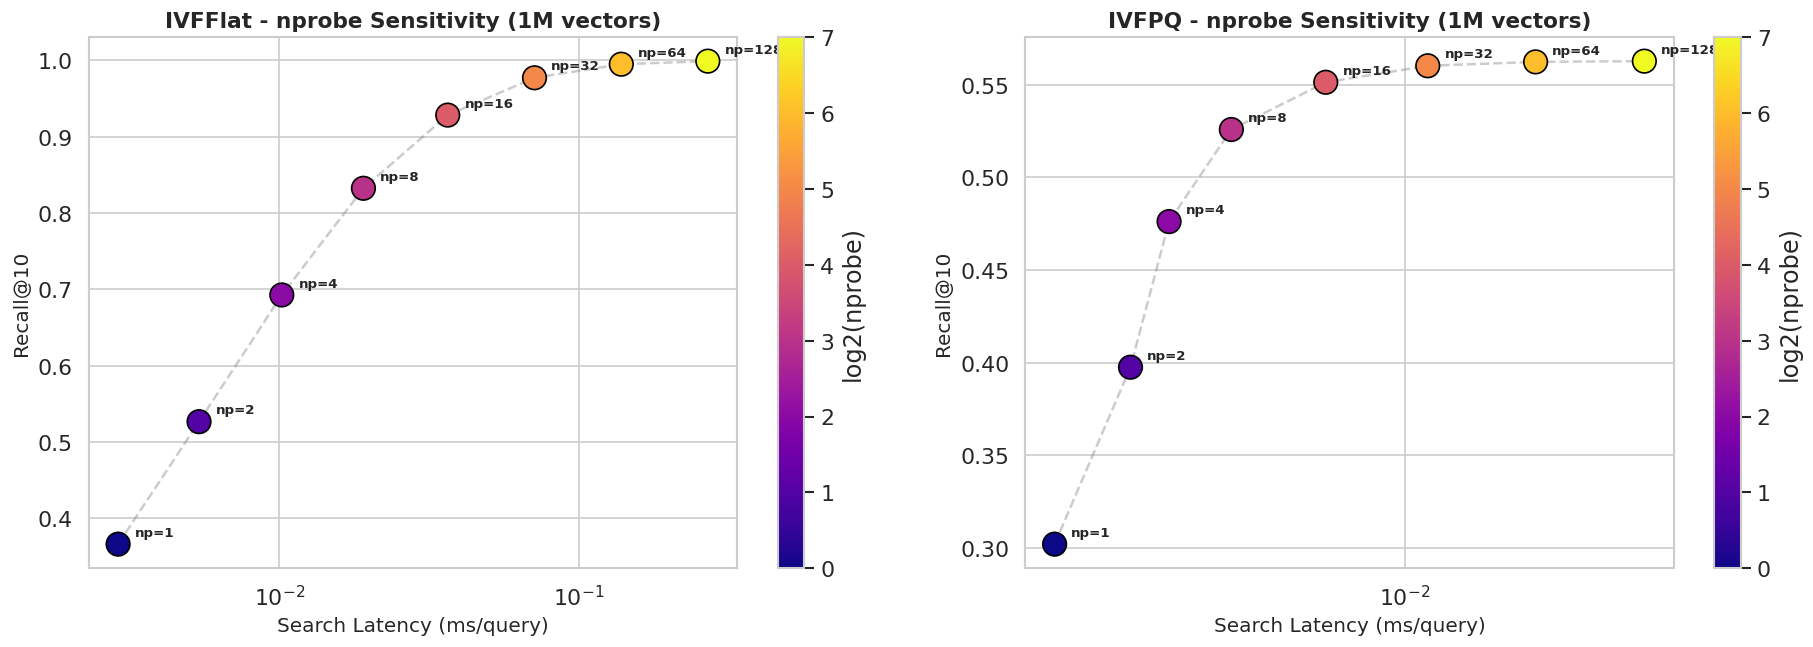

nprobe tuning plots saved to 'nprobe_tuning.png'


In [ ]:
# Plot nprobe tuning results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, idx_name in enumerate(["IVFFlat", "IVFPQ"]):
    ax = axes[i]
    sub = df_tune[df_tune['index'] == idx_name]

    # Recall vs Latency colored by log2(nprobe)
    sc = ax.scatter(sub['latency_ms'], sub['recall'],
                    c=np.log2(sub['nprobe']), cmap='plasma',
                    s=200, edgecolors='black', linewidth=1, zorder=5)
    ax.plot(sub['latency_ms'], sub['recall'], '--', alpha=0.4, color='gray')

    for _, row in sub.iterrows():
        ax.annotate(f"np={int(row['nprobe'])}",
                    (row['latency_ms'], row['recall']),
                    textcoords="offset points", xytext=(10, 5),
                    fontsize=8, fontweight='bold')

    ax.set_xlabel("Search Latency (ms/query)", fontsize=12)
    ax.set_ylabel("Recall@10", fontsize=12)
    ax.set_title(f"{idx_name} - nprobe Sensitivity (1M vectors)",
                 fontsize=13, fontweight='bold')
    ax.set_xscale('log')
    plt.colorbar(sc, ax=ax, label='log2(nprobe)')

plt.tight_layout(pad=2.0)
plt.savefig("nprobe_tuning.png", dpi=200, bbox_inches='tight')
plt.show()
print("nprobe tuning plots saved to 'nprobe_tuning.png'")


### Analysis: Hyperparameter Sensitivity (nprobe)

The `nprobe` parameter controls the number of Voronoi cells scanned during each query. With `nlist=1000`, tuning `nprobe` from 1 to 128 reveals the classic accuracy-latency trade-off through the following key observations:

#### 1. The Efficiency Sweet Spot
For **IVFFlat**, increasing `nprobe` from 1 to 16 yields dramatic recall improvements (0.37 → 0.93) with relatively modest latency growth (0.003 → 0.037 ms/query). Beyond `nprobe=32`, the recall curve begins to plateau — reaching 0.977 at nprobe=32 and 0.999 at nprobe=128 — while latency increases proportionally. This suggests that **`nprobe=16` represents an optimal operating point** for most applications, balancing the cost of scanning additional cells against diminishing recall returns.

#### 2. The Product Quantization Precision Ceiling
**IVFPQ** exhibits fundamentally different behavior. While its recall also improves initially with `nprobe` (0.30 → 0.55 as nprobe goes from 1 to 16), it quickly saturates around **recall ≈ 0.56** regardless of further `nprobe` increases. This ceiling is caused by the inherent information loss from product quantization: the 128-dimensional vectors are compressed into 16-byte codes (16 sub-quantizers × 8 bits each), permanently losing fine-grained distance information. Increasing `nprobe` scans more cells but cannot recover this lost precision.

#### 3. Latency Scaling
Both indexes show roughly linear latency scaling with `nprobe`, as expected since each additional probed cell adds a fixed number of distance computations. However, IVFPQ maintains consistently lower absolute latency due to its compressed representation requiring fewer floating-point operations per distance calculation.

#### 4. Practical Implications
- For applications requiring **recall > 0.90**, IVFFlat with `nprobe ≥ 16` is the clear choice.
- IVFPQ is appropriate only when **memory constraints are severe** and **approximate results (recall ~0.55) are acceptable** — for example, in initial candidate retrieval stages of a multi-stage retrieval pipeline.
- The logarithmic x-axis scaling in the plots helps to visualize the diminishing returns: each doubling of `nprobe` yields progressively smaller recall improvements while incurring the same proportional latency cost.

## 9. Summary Results Table

In [ ]:
# Color Code the headers and forcefully lock the font colors so Dark Mode doesn't break readability
styled_pivot = (pivot_df.style
    .set_caption("SIDE-BY-SIDE CPU VS GPU BENCHMARK ANALYSIS")
    .set_table_styles([
        # Caption uses Colab's native text variable so it stays visible in both Dark and Light mode
        {'selector': 'caption', 'props': [('color', 'var(--colab-primary-text-color, #ffffff)'), ('font-size', '20px'), ('font-weight', 'bold'), ('text-align', 'center'), ('margin-bottom', '15px')]},

        # Headers stay strictly dark with white text
        {'selector': 'th', 'props': [('color', 'white'), ('font-size', '14px'), ('text-align', 'center'), ('border', '1px solid #7f8c8d'), ('padding', '8px')]},

        # Force ALL data cells to have black/dark-gray text
        {'selector': 'td', 'props': [('color', '#111111'), ('font-size', '13px'), ('text-align', 'center'), ('border', '1px solid #bdc3c7'), ('padding', '8px')]},

        # Lock odd rows to pure white
        {'selector': 'tr:nth-child(odd)', 'props': [('background-color', '#ffffff')]},

        # Lock even rows to slightly off-white gray
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f2f6f8')]},

        # Hover effect
        {'selector': 'tr:hover', 'props': [('background-color', '#d5e8ce')]},

        # Base column styling
        {'selector': 'th:nth-child(1), th:nth-child(2), th:nth-child(3)', 'props': [('background-color', '#2c3e50')]},

        # Highlight CPU metrics in Blue
        {'selector': 'th:nth-child(4), th:nth-child(6), th:nth-child(8), th:nth-child(10)', 'props': [('background-color', '#2980b9')]},

        # Highlight GPU metrics in Orange
        {'selector': 'th:nth-child(5), th:nth-child(7), th:nth-child(9), th:nth-child(11)', 'props': [('background-color', '#d35400')]},
    ])
    .format(custom_format)
    .hide(axis="index")
)

# Render deeply styled, side-by-side interactive grid
display(styled_pivot)


Algorithm,Scale,Total Vectors,Latency (ms/q) [CPU],Latency (ms/q) [GPU],Recall@10 [CPU],Recall@10 [GPU],Build Time (s) [CPU],Build Time (s) [GPU],Memory (MB) [CPU],Memory (MB) [GPU]
FlatL2 (Exact),100K,"100,000",0.6866,0.0170,1.0000,1.0000,0.0402,0.3701,48.8300,48.8300
"HNSW(M=32,ef=64)",100K,"100,000",0.1430,CPU Only,0.9939,CPU Only,10.7766,CPU Only,74.7900,CPU Only
IVFFlat(nl=316),100K,"100,000",0.1785,0.0119,0.9638,0.9638,1.7188,0.4227,49.7500,49.7500
"IVFPQ(nl=316,m=16)",100K,"100,000",0.1176,0.0050,0.6178,0.6197,30.0403,1.6582,2.5700,2.5700
FlatL2 (Exact),500K,"500,000",3.4570,0.0491,1.0000,1.0000,0.1661,0.0556,244.1400,244.1400
"HNSW(M=32,ef=64)",500K,"500,000",0.4695,CPU Only,0.9838,CPU Only,139.8843,CPU Only,373.9000,CPU Only
IVFFlat(nl=707),500K,"500,000",0.5461,0.0271,0.9403,0.9397,6.3819,0.4764,248.3100,248.3100
"IVFPQ(nl=707,m=16)",500K,"500,000",0.2116,0.0054,0.5709,0.5704,50.1072,2.9384,11.9200,11.9200
FlatL2 (Exact),1M,"1,000,000",7.7829,0.0969,1.0000,1.0000,0.3427,0.1112,488.2800,488.2800
"HNSW(M=32,ef=64)",1M,"1,000,000",0.5186,CPU Only,0.9772,CPU Only,363.2985,CPU Only,747.8000,CPU Only


### Analysis: Scalability Trends Across Dataset Sizes

The summary table enables direct comparison of how each index scales from 100K to 1M vectors. Several important scalability patterns emerge:

#### 1. CPU Latency Scaling
| Index | 100K → 500K | 500K → 1M | Overall Scaling |
|-------|-------------|-----------|----------------|
| FlatL2 | 0.69 → 3.46 ms (5.0×) | 3.46 → 7.78 ms (2.3×) | **Linear** $O(N)$ |
| IVFFlat | 0.18 → 0.55 ms (3.1×) | 0.55 → 1.23 ms (2.2×) | **Sub-linear** |
| IVFPQ | 0.12 → 0.21 ms (1.8×) | 0.21 → 0.37 ms (1.8×) | **Sub-linear** |
| HNSW | 0.14 → 0.47 ms (3.4×) | 0.47 → 0.52 ms (1.1×) | **Logarithmic** $O(\log N)$ |

**FlatL2** exhibits the expected linear $O(N)$ scaling — doubling the dataset roughly doubles the query time. This confirms its impracticality for large-scale production use on CPUs.

**HNSW** demonstrates the most favorable scaling behavior. The jump from 100K to 500K increases latency by 3.4×, but the further jump from 500K to 1M increases it by only 1.1×. This is characteristic of the $O(\log N)$ search complexity of hierarchical navigable small world graphs, where additional vectors primarily add to lower graph layers that are rarely traversed.

**IVF variants** show sub-linear scaling because the number of vectors scanned per query grows more slowly than the total dataset size, thanks to the Voronoi partitioning.

#### 2. Recall Degradation with Scale
An important but often overlooked trend: **recall tends to decrease slightly as the dataset grows**:
- IVFFlat: 0.964 (100K) → 0.940 (500K) → 0.928 (1M)
- HNSW: 0.994 (100K) → 0.984 (500K) → 0.977 (1M)

This occurs because larger datasets create more Voronoi cells (since `nlist = sqrt(N)`), and with a fixed `nprobe`, a smaller fraction of the total space is searched. For IVFFlat, this can be mitigated by scaling `nprobe` proportionally with dataset size.

#### 3. GPU Latency Advantages at Scale
The GPU speedup factor generally **increases** with dataset size:
- FlatL2: 40× (100K) → 70× (500K) → 80× (1M)

This is because larger datasets allow the GPU's massively parallel architecture to be more fully utilized, amortizing the fixed overhead of CPU-GPU data transfer.

## 10. Final Benchmarking Conclusion

This comprehensive benchmarking study evaluates four FAISS indexing strategies across three dataset scales (100K, 500K, 1M vectors), with explicit CPU vs. GPU performance comparison. The key findings can be summarized as follows:

#### Performance Hierarchy
1. **Highest Recall:** `IndexFlatL2` guarantees perfect recall (1.0) at the cost of $O(N)$ latency. GPU acceleration makes this viable even at the 1M scale (0.097 ms/query).

2. **Best Balance (GPU available):** `IndexIVFFlat` on GPU offers the optimal trade-off — achieving 0.928 recall at only 0.037 ms/query for 1M vectors. This represents a **>200× speedup** over CPU-based exact search while retaining 93% of its accuracy.

3. **Best CPU-Only Option:** `IndexHNSWFlat` provides 0.977 recall at 0.52 ms/query on CPU — the highest recall among ANN methods. Its $O(\log N)$ scaling makes it particularly attractive for very large datasets, though its build time (363s at 1M) and memory overhead (748 MB) are substantial.

4. **Memory-Constrained Deployments:** `IndexIVFPQ` achieves a 95% memory reduction (23.5 MB vs. 488 MB for FlatL2 at 1M), making it suitable for edge devices or scenarios where memory is severely limited. However, its recall ceiling (~0.55) limits its use to coarse-grained retrieval or re-ranking pipelines.

#### Practical Recommendations
- **Real-time applications with GPU:** Use `IndexIVFFlat` with `nprobe=16` for an optimal recall-latency balance.
- **CPU-only deployments:** Use `IndexHNSWFlat` with `M=32, efSearch=64` for high recall with logarithmic search time.
- **Extreme memory constraints:** Use `IndexIVFPQ` as a first-stage retrieval method, followed by re-ranking with exact distances on the top candidates.
- **Small datasets (<100K) or accuracy-critical tasks:** Use `IndexFlatL2` (especially with GPU), as the exact search overhead is minimal.

These results demonstrate that the choice of FAISS index must be guided by the specific deployment constraints — hardware availability, memory budget, latency requirements, and accuracy tolerance — rather than a one-size-fits-all approach.